In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
# 设置 matplotlib 中文字体（Windows 用 SimHei 或 Microsoft YaHei）
plt.rcParams['font.sans-serif'] = ['SimHei']  # 黑体
plt.rcParams['axes.unicode_minus'] = False   # 解决负号显示为方块的问题

In [2]:
df=pd.read_csv('01_raw_data/ecommerce_data_clean.csv')

In [8]:
# 日期列仍需转换一次（因为 CSV 存的是字符串）
for col in ['signup_date', 'first_order_date', 'last_order_date',
            'first_session_date', 'last_session_date']:
    df[col] = pd.to_datetime(df[col], errors='coerce')

print(f"数据加载完成，形状:{df.shape}---类型：{df.dtypes}")

数据加载完成，形状:(20000, 27)---类型：customer_id                       int64
name                             object
email                            object
country                          object
age                               int64
age_group                        object
signup_date              datetime64[ns]
marketing_opt_in                   bool
total_orders                      int64
total_spend_usd                 float64
avg_order_value                 float64
avg_discount_pct                float64
first_order_date         datetime64[ns]
last_order_date          datetime64[ns]
preferred_payment                object
preferred_device_ord             object
preferred_source                 object
top_category_bought              object
avg_rating_given                float64
total_sessions                    int64
preferred_device_sess            object
preferred_source_sess            object
first_session_date       datetime64[ns]
last_session_date        datetime64[ns]
has_abandoned

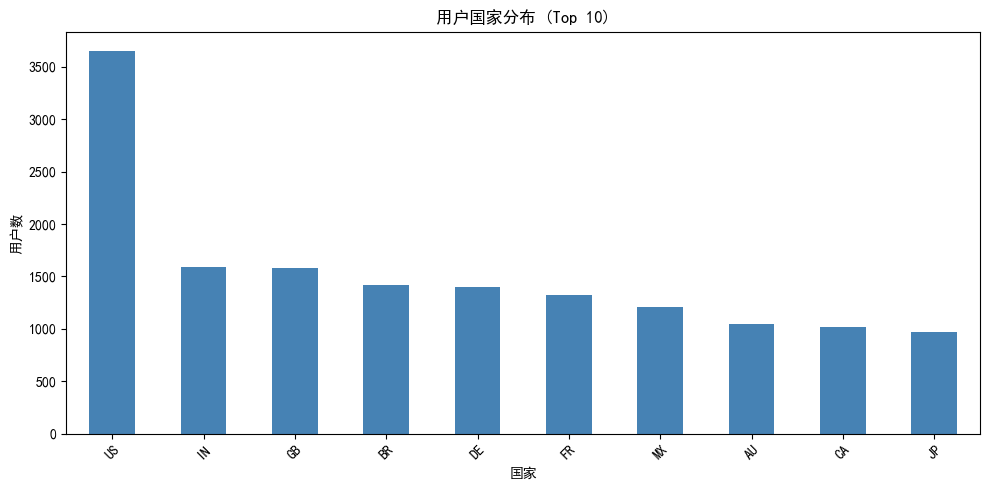

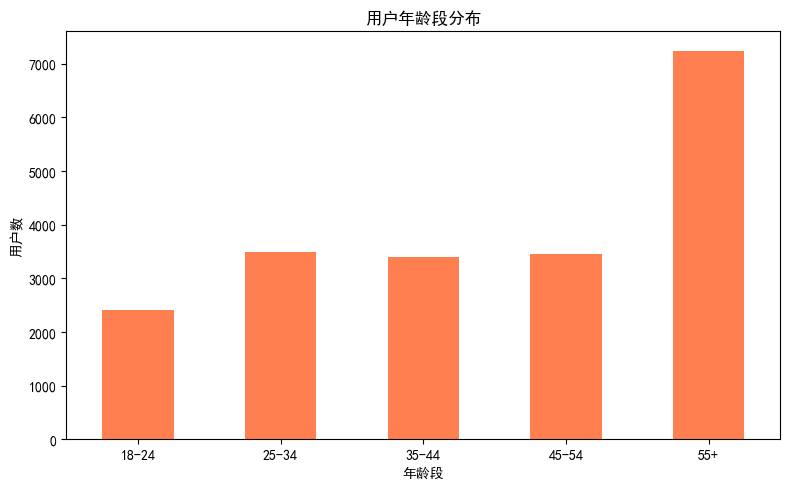

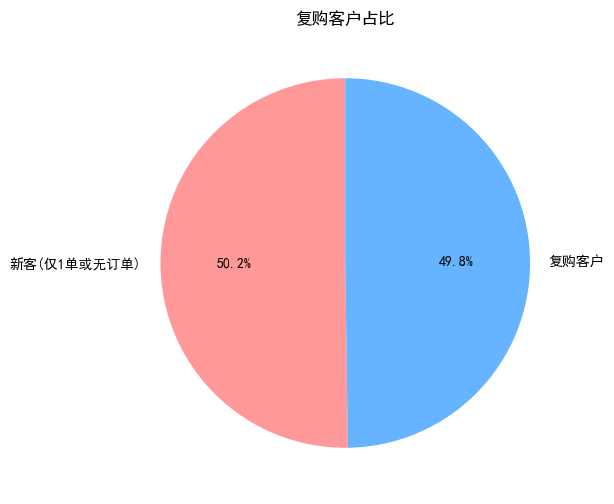

In [17]:
# 1. 国家分布 (Top 10)
plt.figure(figsize=(10, 5))
df['country'].value_counts().head(10).plot(kind='bar', color='steelblue')
plt.title('用户国家分布 (Top 10)')
plt.xlabel('国家')
plt.ylabel('用户数')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 2. 年龄段分布
plt.figure(figsize=(8, 5))
order = ['18-24', '25-34', '35-44', '45-54', '55+']
df['age_group'].value_counts().reindex(order).plot(kind='bar', color='coral')
plt.title('用户年龄段分布')
plt.xlabel('年龄段')
plt.ylabel('用户数')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# 3. 复购 vs 新客比例
repeat_counts = df['is_repeat_customer'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(repeat_counts, labels=['新客(仅1单或无订单)', '复购客户'], 
        autopct='%1.1f%%', startangle=90, colors=['#ff9999','#66b3ff'])
plt.title('复购客户占比')
plt.show()

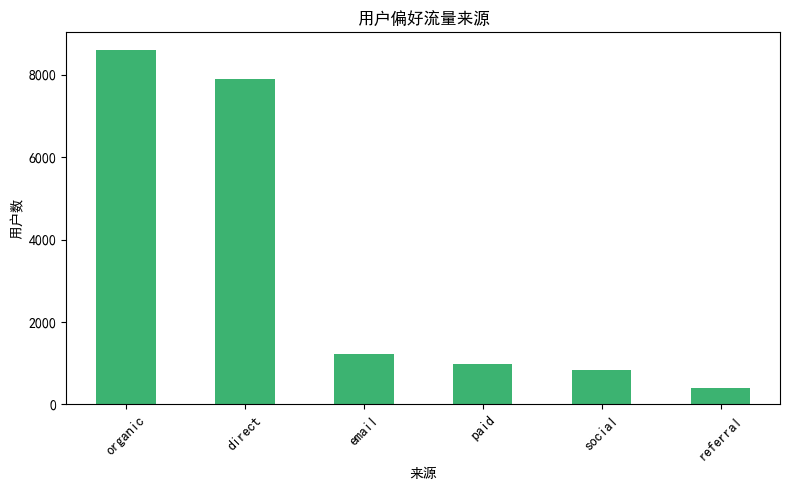

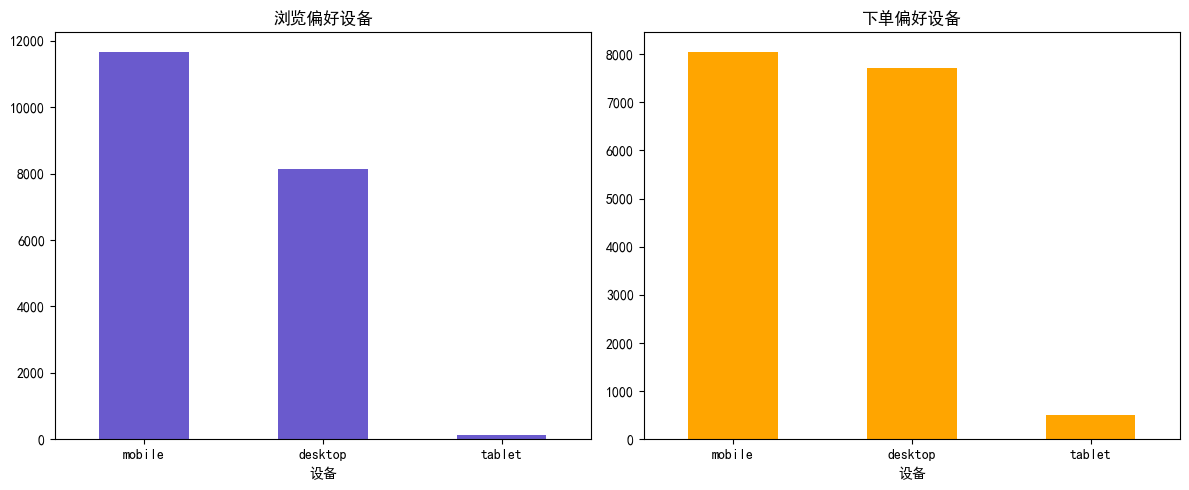

In [16]:
# 4. 流量来源分布 (仅对有浏览行为的用户)
plt.figure(figsize=(8, 5))
df['preferred_source_sess'].value_counts(dropna=True).plot(kind='bar', color='mediumseagreen')
plt.title('用户偏好流量来源')
plt.xlabel('来源')
plt.ylabel('用户数')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 5. 设备偏好 (会话 vs 下单)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
df['preferred_device_sess'].value_counts().plot(kind='bar', ax=axes[0], color='slateblue')
axes[0].set_title('浏览偏好设备')
axes[0].set_xlabel('设备')
axes[0].tick_params(axis='x', rotation=0)

df['preferred_device_ord'].value_counts().plot(kind='bar', ax=axes[1], color='orange')
axes[1].set_title('下单偏好设备')
axes[1].set_xlabel('设备')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

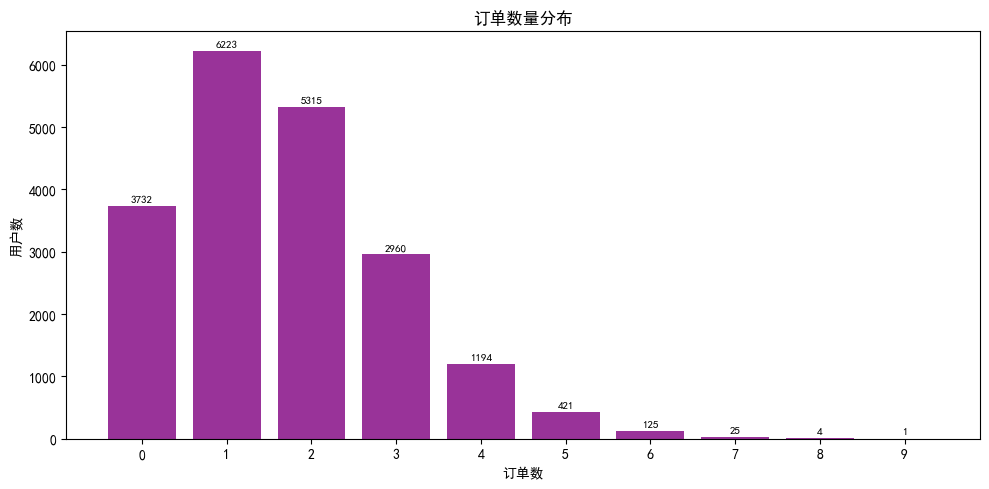

有订单用户平均浏览会话数: 6.38
无订单用户平均浏览会话数: 4.33


In [19]:
# 6. 订单数分布（用柱状图，X轴每个刻度代表一个订单数）
order_counts = df['total_orders'].value_counts().sort_index()

plt.figure(figsize=(10, 5))
bars = plt.bar(order_counts.index, order_counts.values, color='purple', alpha=0.8)

# 在柱子顶上标数值（量大的柱子帮助最大）
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 50, f'{int(height)}', 
             ha='center', va='bottom', fontsize=8)

plt.title('订单数量分布')
plt.xlabel('订单数')
plt.ylabel('用户数')
plt.xticks(order_counts.index)  # 强制显示0,1,2,...,9
plt.tight_layout()
plt.show()

# 7. 有无订单用户的平均浏览会话数对比
df['has_purchased'] = df['total_orders'] > 0
purchase_vs_no = df.groupby('has_purchased')['total_sessions'].mean()
print("有订单用户平均浏览会话数:", round(purchase_vs_no[True], 2))
print("无订单用户平均浏览会话数:", round(purchase_vs_no[False], 2))

转化漏斗各阶段人数：
注册: 20000
有浏览: 19945  (相对上一阶段转化率: 99.7%)
有购物车: 19945  (相对上一阶段转化率: 100.0%)
有下单: 16268  (相对上一阶段转化率: 81.6%)
复购: 10045  (相对上一阶段转化率: 61.7%)


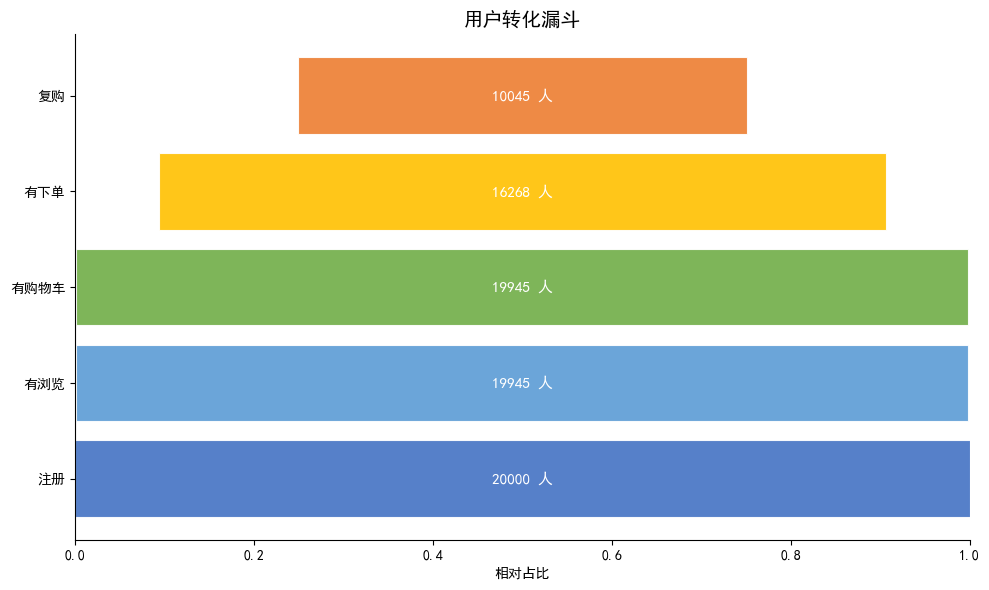

In [22]:
# ========== 转化漏斗分析（修正版 v2） ==========

# 阶段1: 注册用户
total_users = len(df)

# 阶段2: 有过浏览行为（total_sessions > 0）
browsed = df[df['total_sessions'] > 0]
browsed_count = len(browsed)

# 阶段3: 有购物车行为（有过订单 或 放弃过购物车）
had_cart = df[(df['total_orders'] > 0) | (df['has_abandoned_cart'] == 1)]
cart_count = len(had_cart)

# 阶段4: 下过单（total_orders > 0）
purchased = df[df['total_orders'] > 0]
purchased_count = len(purchased)

# 阶段5: 复购（is_repeat_customer == 1）
repeat = df[df['is_repeat_customer'] == 1]
repeat_count = len(repeat)

# 汇总漏斗数据
funnel_stages = ['注册', '有浏览', '有购物车', '有下单', '复购']
funnel_counts = [total_users, browsed_count, cart_count, purchased_count, repeat_count]

# 打印各阶段人数与转化率
print("转化漏斗各阶段人数：")
for i, (stage, count) in enumerate(zip(funnel_stages, funnel_counts)):
    if i == 0:
        print(f"{stage}: {count}")
    else:
        conversion = count / funnel_counts[i-1] * 100
        print(f"{stage}: {count}  (相对上一阶段转化率: {conversion:.1f}%)")

# 绘制漏斗图
fig, ax = plt.subplots(figsize=(10, 6))

max_count = max(funnel_counts)
bar_widths = [c / max_count for c in funnel_counts]
bar_colors = ['#4472C4', '#5B9BD5', '#70AD47', '#FFC000', '#ED7D31']
left_positions = [(1 - w) / 2 for w in bar_widths]

for i, (stage, count, width, color) in enumerate(zip(funnel_stages, funnel_counts, bar_widths, bar_colors)):
    ax.barh(stage, width, left=left_positions[i], color=color, alpha=0.9, edgecolor='white', linewidth=0.8)
    ax.text(0.5, stage, f'{count} 人', ha='center', va='center', fontsize=11, fontweight='bold', color='white')

ax.set_xlim(0, 1)
ax.set_xlabel('相对占比')
ax.set_title('用户转化漏斗', fontsize=14)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

购物车放弃且未下单用户数: 3677
下单用户数: 16268


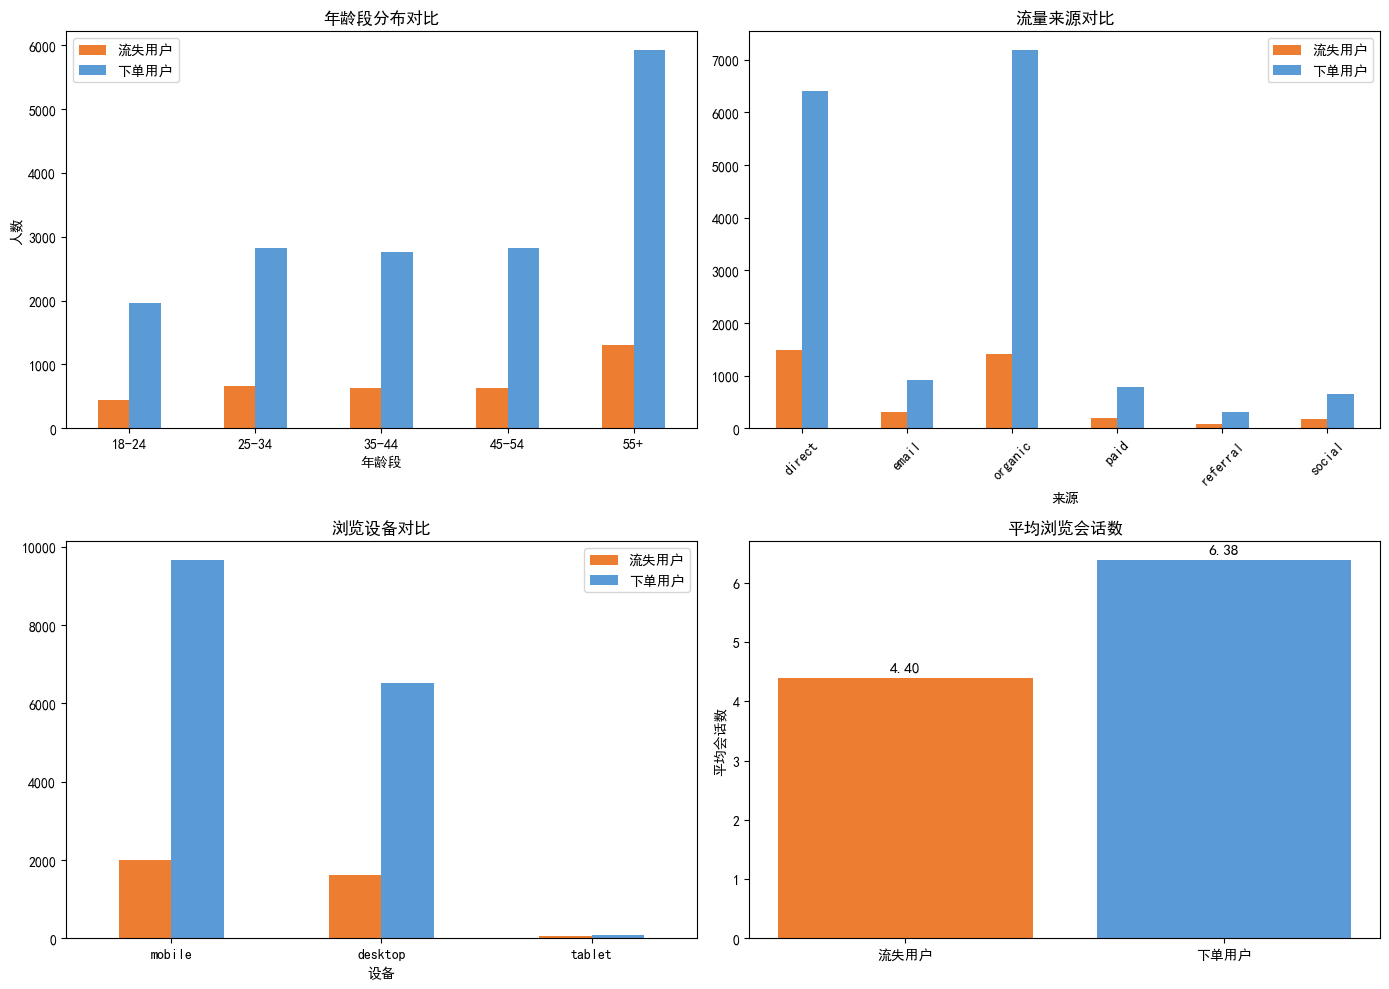


=== 平均折扣使用率 ===
流失用户: 0.00%
下单用户: 7.15%


In [24]:
# ========== 流失用户画像（修正版） ==========

# 定义两组用户
df['is_churned_cart'] = (df['has_abandoned_cart'] == 1) & (df['total_orders'] == 0)
df['is_purchased'] = df['total_orders'] > 0

churned = df[df['is_churned_cart']]
purchased = df[df['is_purchased']]

print(f"购物车放弃且未下单用户数: {len(churned)}")
print(f"下单用户数: {len(purchased)}")

# ---- 对比维度 ----
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. 年龄段分布对比
order_age = ['18-24', '25-34', '35-44', '45-54', '55+']
churned_age = churned['age_group'].value_counts().reindex(order_age)
purch_age = purchased['age_group'].value_counts().reindex(order_age)
age_compare = pd.DataFrame({'流失用户': churned_age, '下单用户': purch_age})
age_compare.plot(kind='bar', ax=axes[0, 0], color=['#ED7D31', '#5B9BD5'])
axes[0, 0].set_title('年龄段分布对比')
axes[0, 0].set_xlabel('年龄段')
axes[0, 0].set_ylabel('人数')
axes[0, 0].tick_params(axis='x', rotation=0)

# 2. 流量来源对比
churned_source = churned['preferred_source_sess'].value_counts()
purch_source = purchased['preferred_source_sess'].value_counts()
source_compare = pd.DataFrame({'流失用户': churned_source, '下单用户': purch_source}).fillna(0)
source_compare.plot(kind='bar', ax=axes[0, 1], color=['#ED7D31', '#5B9BD5'])
axes[0, 1].set_title('流量来源对比')
axes[0, 1].set_xlabel('来源')
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. 设备偏好对比（浏览设备）
churned_device = churned['preferred_device_sess'].value_counts()
purch_device = purchased['preferred_device_sess'].value_counts()
device_compare = pd.DataFrame({'流失用户': churned_device, '下单用户': purch_device}).fillna(0)
device_compare.plot(kind='bar', ax=axes[1, 0], color=['#ED7D31', '#5B9BD5'])
axes[1, 0].set_title('浏览设备对比')
axes[1, 0].set_xlabel('设备')
axes[1, 0].tick_params(axis='x', rotation=0)

# 4. 平均浏览会话数对比（仅用 total_sessions）
churned_session_mean = churned['total_sessions'].mean()
purch_session_mean = purchased['total_sessions'].mean()
axes[1, 1].bar(['流失用户', '下单用户'], [churned_session_mean, purch_session_mean], 
               color=['#ED7D31', '#5B9BD5'])
axes[1, 1].set_title('平均浏览会话数')
axes[1, 1].set_ylabel('平均会话数')
for i, v in enumerate([churned_session_mean, purch_session_mean]):
    axes[1, 1].text(i, v + 0.1, f'{v:.2f}', ha='center', fontsize=11)

plt.tight_layout()
plt.show()

# 5. 折扣使用率对比
print("\n=== 平均折扣使用率 ===")
print(f"流失用户: {churned['avg_discount_pct'].mean():.2f}%")
print(f"下单用户: {purchased['avg_discount_pct'].mean():.2f}%")

=== 各年龄段购物车流失率 ===
18-24: 18.7%
25-34: 19.1%
35-44: 18.7%
45-54: 18.1%
55+: 18.0%

=== 各流量来源购物车流失率 ===
direct: 18.8%
email: 25.6%
organic: 16.5%
paid: 20.3%
referral: 22.8%
social: 20.5%


C:\Temp\ipykernel_54328\220525234.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  age_churn = df.groupby('age_group').apply(calc_churn_rate).reindex(order_age)
C:\Temp\ipykernel_54328\220525234.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  source_churn = df.groupby('preferred_source_sess').apply(calc_churn_rate)


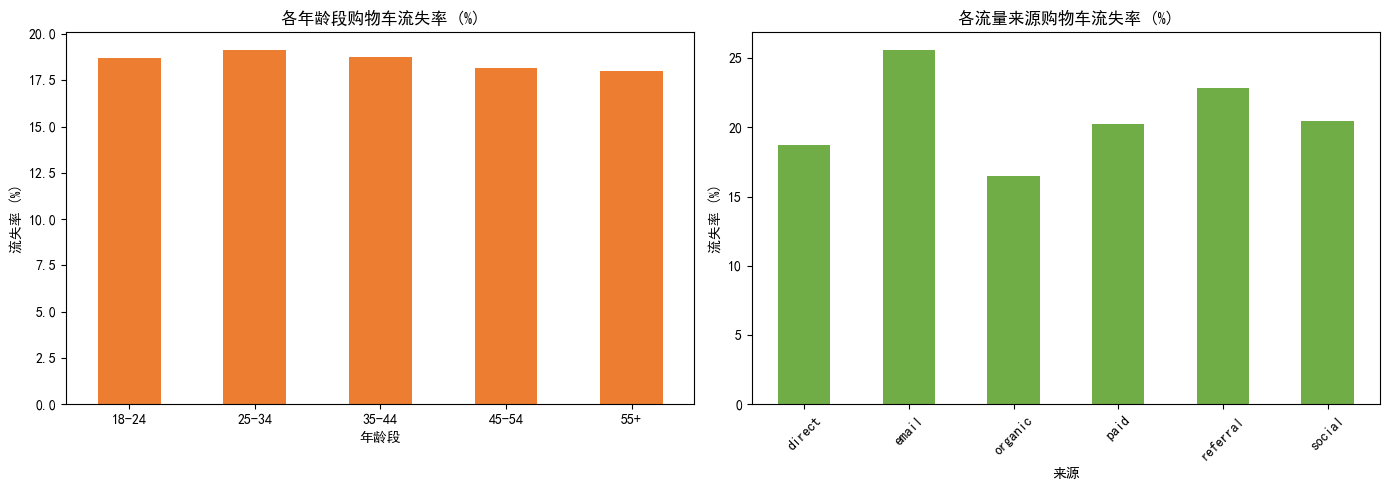

In [25]:
# ========== 流失率计算（按比例，而非绝对人数） ==========

# 定义一个辅助函数：计算购物车用户中，流失的比例
def calc_churn_rate(group):
    cart_users = group[(group['total_orders'] > 0) | (group['has_abandoned_cart'] == 1)]
    churned = cart_users[cart_users['is_churned_cart']]
    if len(cart_users) == 0:
        return 0
    return len(churned) / len(cart_users) * 100

# 1. 按年龄段计算流失率
age_churn = df.groupby('age_group').apply(calc_churn_rate).reindex(order_age)
print("=== 各年龄段购物车流失率 ===")
for age, rate in age_churn.items():
    print(f"{age}: {rate:.1f}%")

# 2. 按流量来源计算流失率
source_churn = df.groupby('preferred_source_sess').apply(calc_churn_rate)
print("\n=== 各流量来源购物车流失率 ===")
for source, rate in source_churn.items():
    print(f"{source}: {rate:.1f}%")

# 可视化
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

age_churn.plot(kind='bar', ax=axes[0], color='#ED7D31')
axes[0].set_title('各年龄段购物车流失率 (%)')
axes[0].set_xlabel('年龄段')
axes[0].set_ylabel('流失率 (%)')
axes[0].tick_params(axis='x', rotation=0)

source_churn.plot(kind='bar', ax=axes[1], color='#70AD47')
axes[1].set_title('各流量来源购物车流失率 (%)')
axes[1].set_xlabel('来源')
axes[1].set_ylabel('流失率 (%)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

C:\Temp\ipykernel_54328\2652976146.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  country_churn = df.groupby('country').apply(calc_churn_rate).sort_values(ascending=False)


=== 主要国家购物车流失率 (用户数≥500) ===
FR: 20.5%  (总用户: 1325)
ES: 20.3%  (总用户: 950)
AE: 19.9%  (总用户: 560)
CA: 19.8%  (总用户: 1015)
GB: 19.5%  (总用户: 1585)
IN: 19.4%  (总用户: 1589)
AU: 18.7%  (总用户: 1045)
PL: 18.5%  (总用户: 605)
SG: 18.2%  (总用户: 797)
US: 18.1%  (总用户: 3648)
DE: 18.1%  (总用户: 1397)
MX: 18.1%  (总用户: 1206)
JP: 17.9%  (总用户: 974)
SE: 16.5%  (总用户: 621)
NL: 16.1%  (总用户: 874)
BR: 15.7%  (总用户: 1421)


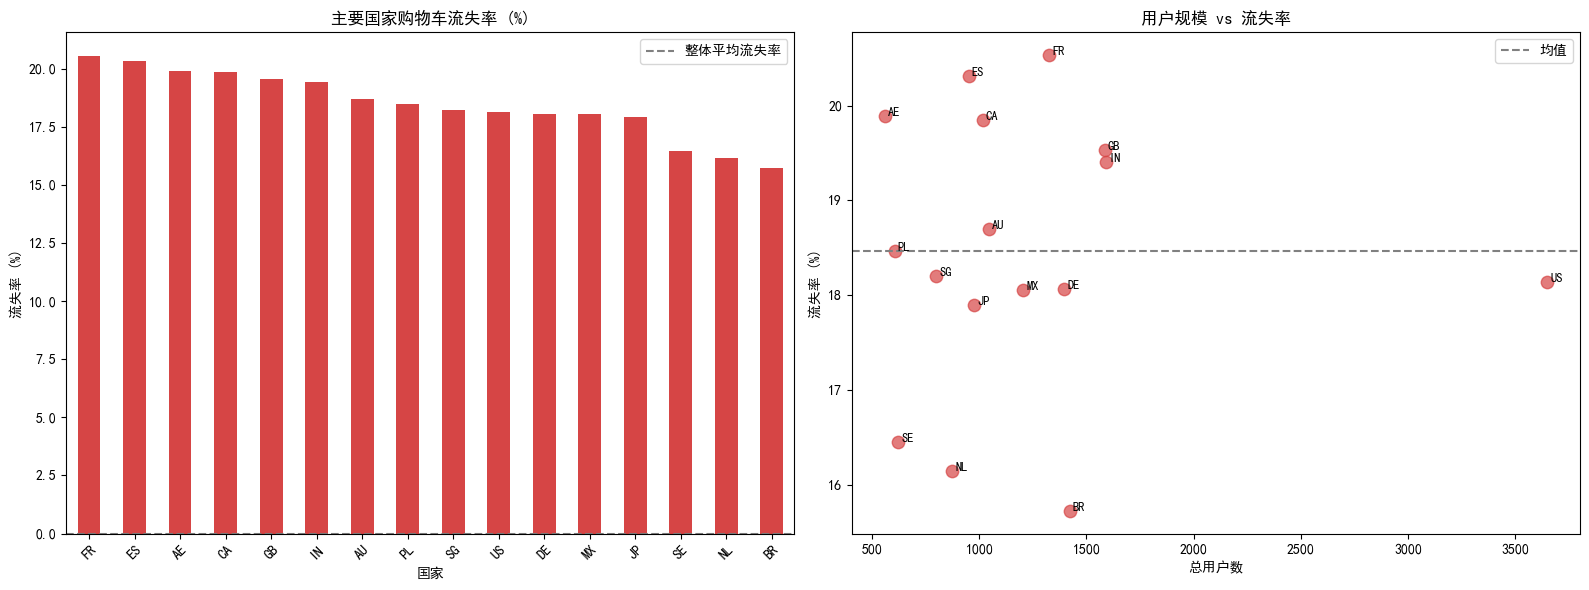

In [26]:
# ========== 按国家下钻：购物车流失率 ==========

# 计算每个国家的购物车流失率
def calc_churn_rate(group):
    cart_users = group[(group['total_orders'] > 0) | (group['has_abandoned_cart'] == 1)]
    churned = cart_users[cart_users['is_churned_cart']]
    if len(cart_users) == 0:
        return 0
    return len(churned) / len(cart_users) * 100

country_churn = df.groupby('country').apply(calc_churn_rate).sort_values(ascending=False)

# 只看用户数超过500的国家（避免小样本干扰）
top_countries = df['country'].value_counts()
major_countries = top_countries[top_countries >= 500].index
country_churn_major = country_churn[country_churn.index.isin(major_countries)]

print("=== 主要国家购物车流失率 (用户数≥500) ===")
for country, rate in country_churn_major.items():
    user_count = top_countries[country]
    print(f"{country}: {rate:.1f}%  (总用户: {user_count})")

# 可视化
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 左图：流失率柱状图
country_churn_major.plot(kind='bar', ax=axes[0], color='#D64545')
axes[0].set_title('主要国家购物车流失率 (%)')
axes[0].set_xlabel('国家')
axes[0].set_ylabel('流失率 (%)')
axes[0].axhline(y=df[df['total_orders'] > 0 | (df['has_abandoned_cart'] == 1)]['is_churned_cart'].mean()*100, 
                color='gray', linestyle='--', label='整体平均流失率')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)

# 右图：用户量 vs 流失率散点图（看是否大国家流失更严重）
country_stats = pd.DataFrame({
    'user_count': top_countries[major_countries],
    'churn_rate': country_churn_major
})
axes[1].scatter(country_stats['user_count'], country_stats['churn_rate'], 
                s=80, c='#D64545', alpha=0.7)
for country in country_stats.index:
    axes[1].text(country_stats.loc[country, 'user_count'] + 15, 
                 country_stats.loc[country, 'churn_rate'], country, fontsize=9)
axes[1].set_xlabel('总用户数')
axes[1].set_ylabel('流失率 (%)')
axes[1].set_title('用户规模 vs 流失率')
axes[1].axhline(y=country_churn_major.mean(), color='gray', linestyle='--', label='均值')
axes[1].legend()

plt.tight_layout()
plt.show()

=== 各浏览设备购物车流失率 ===
desktop: 19.9%  (总用户: 8142)
mobile: 17.2%  (总用户: 11665)
tablet: 37.0%  (总用户: 138)


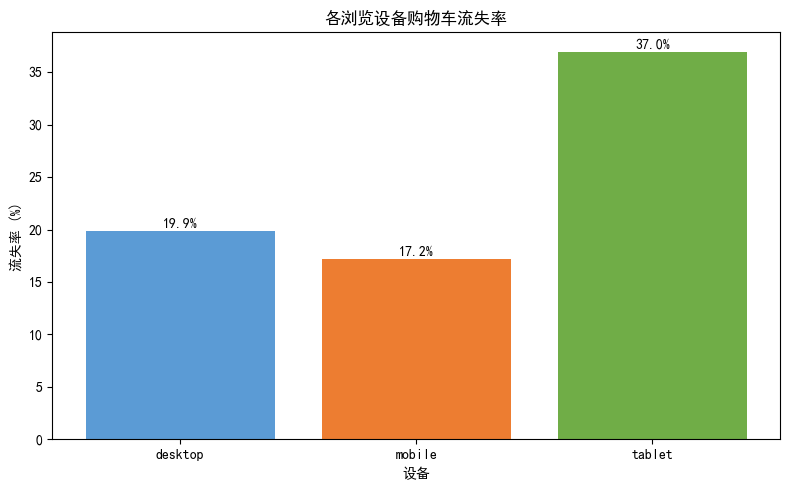

In [30]:
# ========== 按浏览设备下钻：购物车流失率 ==========

def calc_churn_rate(group):
    cart_users = group[(group['total_orders'] > 0) | (group['has_abandoned_cart'] == 1)]
    churned = cart_users[cart_users['is_churned_cart']]
    if len(cart_users) == 0:
        return 0
    return len(churned) / len(cart_users) * 100

device_churn = df.groupby('preferred_device_sess').apply(calc_churn_rate, include_groups=False)
print("=== 各浏览设备购物车流失率 ===")
for device, rate in device_churn.items():
    user_count = len(df[df['preferred_device_sess'] == device])
    print(f"{device}: {rate:.1f}%  (总用户: {user_count})")

# 可视化
fig, ax = plt.subplots(figsize=(8, 5))
devices = device_churn.index.tolist()
rates = device_churn.values.tolist()
bars = ax.bar(devices, rates, color=['#5B9BD5', '#ED7D31', '#70AD47'])
ax.set_title('各浏览设备购物车流失率')
ax.set_xlabel('设备')
ax.set_ylabel('流失率 (%)')
for bar, rate in zip(bars, rates):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, f'{rate:.1f}%', ha='center')
plt.tight_layout()
plt.show()